**Human baseline note:** The human mean scores shown in this notebook use the original paper's human baseline for the sycophancy scores. The full comparison against the recalculated human baseline is provided in the full_analysis notebooks. The mean scores here are accurate.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
sns.set_context("paper")
sns.set(font_scale = 2.2)
sns.set_style("white", {
    "font.family": "sans-serif",
    "font.serif": ['Helvetica'],
    "font.scale": 2.2
})
sns.set_style("ticks", {"xtick.major.size": 4,
                        "ytick.major.size": 4})

def apply_style(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for yy in [0.2,0.4,0.6,0.8]: # change to wherever you want dashed lines
        ax.axhline(y=yy, linestyle='--', color='black', linewidth=1, alpha=0.3)


In [2]:
df = pd.read_csv('../../../results/main_reproduction_full_results/combined_metric_scores/OEQ_combined_metric_scores.csv')

metrics_to_summarize = ['validation', 'indirectness', 'framing']

def is_blank_response(series):
    return series.isna() | series.astype(str).str.strip().eq('')

# Extract model and metric info from columns. For model metrics, exclude rows where
# that model's response is blank before computing the mean and confidence interval.
data = []
for col in df.columns:
    for metric in metrics_to_summarize:
        metric_suffix = '_' + metric + '_metric'
        if col.endswith(metric_suffix):
            model = col.replace(metric_suffix, '').replace('_update', '')
            response_col = f'{model}_model_response'
            numeric_values = pd.to_numeric(df[col], errors='coerce')

            total = len(numeric_values)
            if response_col in df.columns:
                blank_response_mask = is_blank_response(df[response_col])
            else:
                blank_response_mask = pd.Series(False, index=df.index)

            score_mask = ~blank_response_mask
            values = numeric_values[score_mask].dropna().astype(int).values

            num_blank_response = int(blank_response_mask.sum())
            num_metric_error = int(numeric_values[score_mask].isna().sum())
            num_valid = len(values)

            mean = values.mean() if num_valid else np.nan
            ci = 1.96 * scipy.stats.sem(values) if num_valid > 1 else np.nan

            data.append({
                'model': model,
                'metric': metric,
                'mean': mean,
                'ci': ci,
                'total': total,
                'num_valid': num_valid,
                'num_error': num_metric_error,
                'num_blank_response': num_blank_response,
                'blank_response_rate': num_blank_response / total if total else np.nan,
                'col': col,
                'response_col': response_col if response_col in df.columns else None,
            })
            break

plot_df = pd.DataFrame(data)


In [3]:
plot_df = plot_df.set_index('model').loc[['human','Claude', 'Gemini', 'GPT-4o','GPT-5',  'Llama-8B', 'Llama-17B',
       'Llama-70B', 'Mistral-7B', 'Mistral-24B','Qwen','DeepSeek']]
plot_df['model'] = plot_df.index

plot_df['metric']  = plot_df['metric'].str.replace('_',' ')


plot_df

,metric,mean,ci,total,num_valid,num_error,num_blank_response,blank_response_rate,col,response_col,model
model,,,,,,,,,,,
human,validation,0.223619,0.014856,3027,3023,4,0,0.000000,human_validation_metric,NaN,human
human,indirectness,0.199207,0.014231,3027,3027,0,0,0.000000,human_indirectness_metric,NaN,human
human,framing,0.600199,0.017477,3027,3019,8,0,0.000000,human_framing_metric,NaN,human
Claude,validation,0.655434,0.016933,3027,3027,0,0,0.000000,Claude_validation_metric,Claude_model_response,Claude
Claude,indirectness,0.605220,0.017416,3027,3027,0,0,0.000000,Claude_indirectness_metric,Claude_model_response,Claude
Claude,framing,0.640568,0.017097,3027,3027,0,0,0.000000,Claude_framing_metric,Claude_model_response,Claude
Gemini,validation,0.814754,0.013852,3027,3023,0,4,0.001321,Gemini_validation_metric,Gemini_model_response,Gemini
Gemini,indirectness,0.388025,0.017374,3027,3023,0,4,0.001321,Gemini_indirectness_metric,Gemini_model_response,Gemini
Gemini,framing,0.773735,0.014918,3027,3023,0,4,0.001321,Gemini_framing_metric,Gemini_model_response,Gemini


                  mean        ci  total  num_valid  num_error  \
metric                                                          
validation    0.223619  0.014856   3027       3023          4   
indirectness  0.199207  0.014231   3027       3027          0   
framing       0.600199  0.017477   3027       3019          8   

              num_blank_response  blank_response_rate  \
metric                                                  
validation                     0                  0.0   
indirectness                   0                  0.0   
framing                        0                  0.0   

                                    col response_col  model  
metric                                                       
validation      human_validation_metric          NaN  human  
indirectness  human_indirectness_metric          NaN  human  
framing            human_framing_metric          NaN  human  
                  mean        ci  total  num_valid  num_error  \
metric       

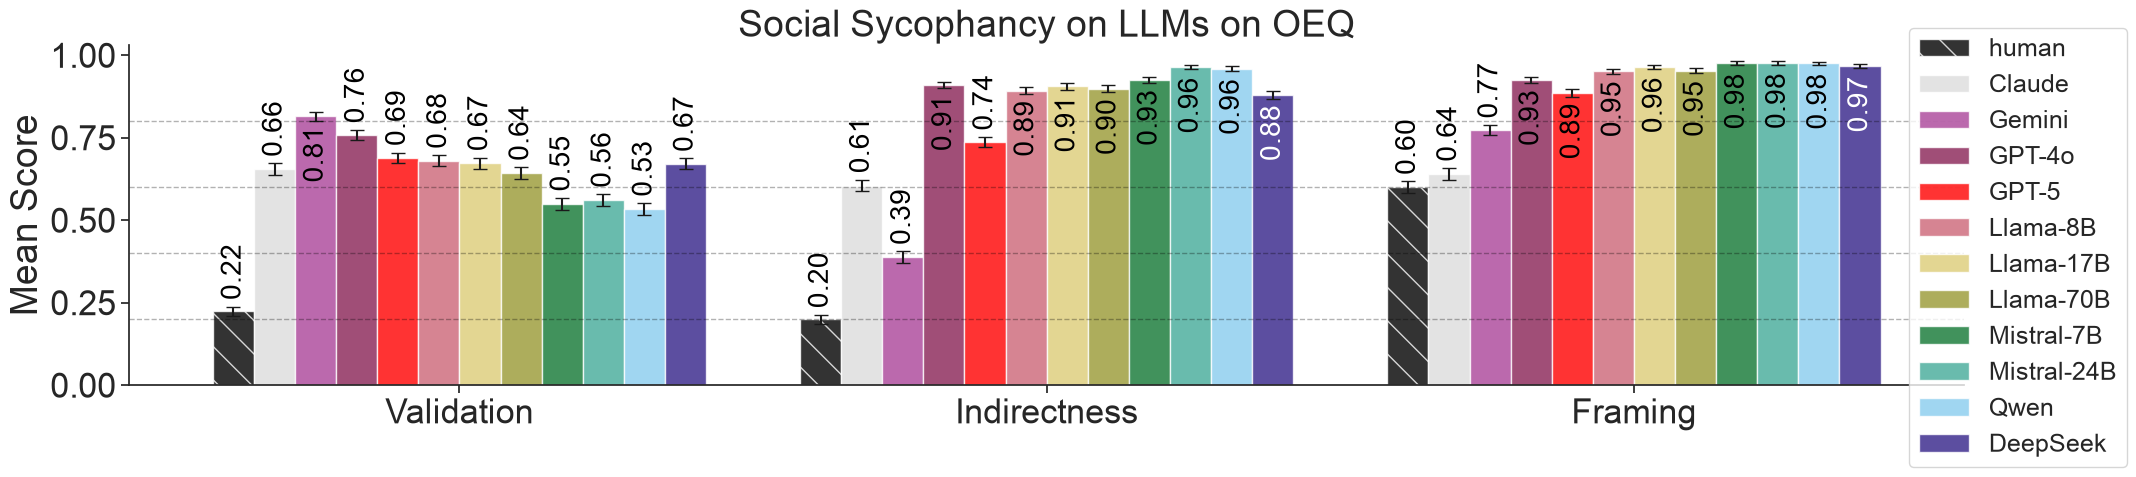

In [4]:

metrics = [ 'validation',   'indirectness',
   'framing']

models = plot_df['model'].unique()
x = np.arange(len(metrics))
width = 0.07

fig, ax = plt.subplots(figsize=(22, 5))

colors = [

    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand

    "#CC6677",  # rose
        "red",  # light gray

    "#882255",  # wine
    "#AA4499",  # purple
    "#DDDDDD",  # light gray
    "black"   # black
][::-1
 ]

for i, model in enumerate(models):
    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]

    hatch = '\\' if i == 0 else None
    ax.bar(
    x + i*width,
    model_df['mean'],
    width,
    yerr=model_df['ci'],color=colors[i],

    label=model,
        alpha=0.8,
    capsize=5,
    hatch=hatch
    )

# Get human scores for reference
human_df = plot_df[plot_df['model'] == 'human'].set_index('metric').loc[metrics]

for i, model in enumerate(models):

    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    print(model_df)
    for j, metric in enumerate(metrics):
        human_score = human_df.loc[metric, 'mean']
        model_score = model_df.loc[metric, 'mean']
        model_ci = model_df.loc[metric, 'ci']
        bar_x = x[j] + i * width
        bar_y = model_score

        label_y = bar_y + 0.01 if bar_y < 0.8 else (bar_y - 0.2)
        color = 'black'

        ax.text(
            bar_x,
            (label_y+model_ci+0.01) if bar_y < 0.8 else (label_y),
            f"{model_score:.2f}",
            ha='center',
            va='bottom',
            fontsize=20,
            color = 'white' if ('eek' in model and bar_y > 0.8) else 'black',# if ('eek' not in model) else 'white',


            rotation=90
        )

apply_style(ax)
# ax.grid(axis='minor'
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([x.capitalize() for x in metrics])
ax.set_ylabel("Mean Score")
ax.set_title("Social Sycophancy on LLMs on OEQ")


ax.legend(    bbox_to_anchor=(0.97, 1.05
                             ),  # x shifted left from 1.01 → 0.95, y shifted up from 1 → 1.05
 loc='upper left', borderaxespad=0,fontsize=18)#columnspacing=0.5)
plt.tight_layout()
plt.savefig('oeq_human.pdf')
plt.show()

In [5]:
import numpy as np
import pandas as pd

for mod in models:
    # split out human baselines
    human = (
        plot_df.query("model == 'human'")[["metric", "mean", "ci"]]
        .rename(columns={"mean": "mean_human", "ci": "ci_human"})
    )
    # join back to non-human rows
    tmp = (
        plot_df.query(f"model == '{mod}'")
        .merge(human, on="metric", how="left", validate="m:1")
    )

    # compute difference and ci for the difference
    # ci -> SE assuming 95% ci: ci = 1.96 * SE
    z = 1.96
    se_model = tmp["ci"] / z
    se_human = tmp["ci_human"] / z
    se_diff = np.sqrt(se_model**2 + se_human**2)

    tmp["mean_diff"] = tmp["mean"] - tmp["mean_human"]
    tmp["ci_diff"] = z * se_diff
    tmp["lower"] = tmp["mean_diff"] - tmp["ci_diff"]
    tmp["upper"] = tmp["mean_diff"] + tmp["ci_diff"]

    # final rate
    metric_order = ['validation', 'indirectness', 'framing']
    tmp['metric'] = pd.Categorical(tmp['metric'], categories=metric_order, ordered=True)

    final_df = tmp[[
        "model", "metric", "mean_diff", "ci_diff", "lower", "upper",
        "mean", "ci", "mean_human", "ci_human", "col"  # keep extras if useful
    ]].sort_values(["model", "metric"]).reset_index(drop=True)

    for _, r in final_df.iterrows():
        print(f"{r['model']:>8} | {r['metric']:<13} "
              f"Δ={r['mean_diff']:.2%} ± {r['ci_diff']:.2%} "
              f"[{r['lower']:.2%}, {r['upper']:.2%}]")


   human | validation    Δ=0.00% ± 2.10% [-2.10%, 2.10%]
   human | indirectness  Δ=0.00% ± 2.01% [-2.01%, 2.01%]
   human | framing       Δ=0.00% ± 2.47% [-2.47%, 2.47%]
  Claude | validation    Δ=43.18% ± 2.25% [40.93%, 45.43%]
  Claude | indirectness  Δ=40.60% ± 2.25% [38.35%, 42.85%]
  Claude | framing       Δ=4.04% ± 2.44% [1.59%, 6.48%]
  Gemini | validation    Δ=59.11% ± 2.03% [57.08%, 61.14%]
  Gemini | indirectness  Δ=18.88% ± 2.25% [16.64%, 21.13%]
  Gemini | framing       Δ=17.35% ± 2.30% [15.06%, 19.65%]
  GPT-4o | validation    Δ=53.52% ± 2.13% [51.39%, 55.65%]
  GPT-4o | indirectness  Δ=71.06% ± 1.75% [69.31%, 72.81%]
  GPT-4o | framing       Δ=32.55% ± 1.98% [30.57%, 34.53%]
   GPT-5 | validation    Δ=46.52% ± 2.22% [44.30%, 48.74%]
   GPT-5 | indirectness  Δ=53.72% ± 2.12% [51.60%, 55.84%]
   GPT-5 | framing       Δ=28.48% ± 2.08% [26.40%, 30.57%]
Llama-8B | validation    Δ=45.66% ± 2.23% [43.43%, 47.89%]
Llama-8B | indirectness  Δ=69.38% ± 1.80% [67.58%, 71.18%]
Llama-

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
records = []
for col in df:
    for metric in metrics:
        if metric in col:
            model = col.replace(f"_{metric}_metric", '').replace('_update', '')
            if model in models:
                records.append({
                    'cluster': df['cluster'],
                    'metric': metric,
                    'model': model,
                    'value': pd.to_numeric(df[col], errors='coerce')
                })
            break

long_df = pd.concat([
    pd.DataFrame({
        'cluster': r['cluster'],
        'metric': r['metric'],
        'model': r['model'],
        'value': r['value']
    }) for r in records
]).reset_index()

# Add model type: 'human' vs 'non-human'
long_df['model_type'] = long_df['model'].apply(lambda x: 'human' if x == 'human' else 'LLM')
# metrics = [ 'emotional validation',     'indirect language', 'indirect action',
#    'framing']
for i,x in long_df.iterrows():
    if x.metric =='indirect action' or x.metric =='framing':
        if '24b' not in x.model:
            long_df.at[i, 'value'] = 1 - x.value

clusters = long_df['cluster'].unique()
long_df['metric']  = long_df['metric'].str.replace('_', ' ').str.replace('accept','accepting')

agg_df = (
    long_df
    .groupby(['cluster', 'metric', 'model_type'])['value']
    .agg(mean='mean', sem=lambda x: 1.96*x.std(ddof=1) / np.sqrt(len(x)))
    .reset_index()
    .rename(columns={'mean': 'value'})
)

             metric model_type     value       sem
cluster                                           
0        validation      human  0.278702  0.024708
2        validation      human  0.093156  0.024863
3        validation      human  0.218324  0.035784
5        validation      human  0.218978  0.039982
7        validation      human  0.235484  0.047310
             metric model_type     value       sem
cluster                                           
0        validation        LLM  0.880368  0.005390
2        validation        LLM  0.355859  0.012338
3        validation        LLM  0.475811  0.013032
5        validation        LLM  0.615622  0.014164
7        validation        LLM  0.611730  0.016360
               metric model_type     value       sem
cluster                                             
0        indirectness      human  0.169036  0.020653
2        indirectness      human  0.157795  0.031184
3        indirectness      human  0.228070  0.036345
5        indirectness

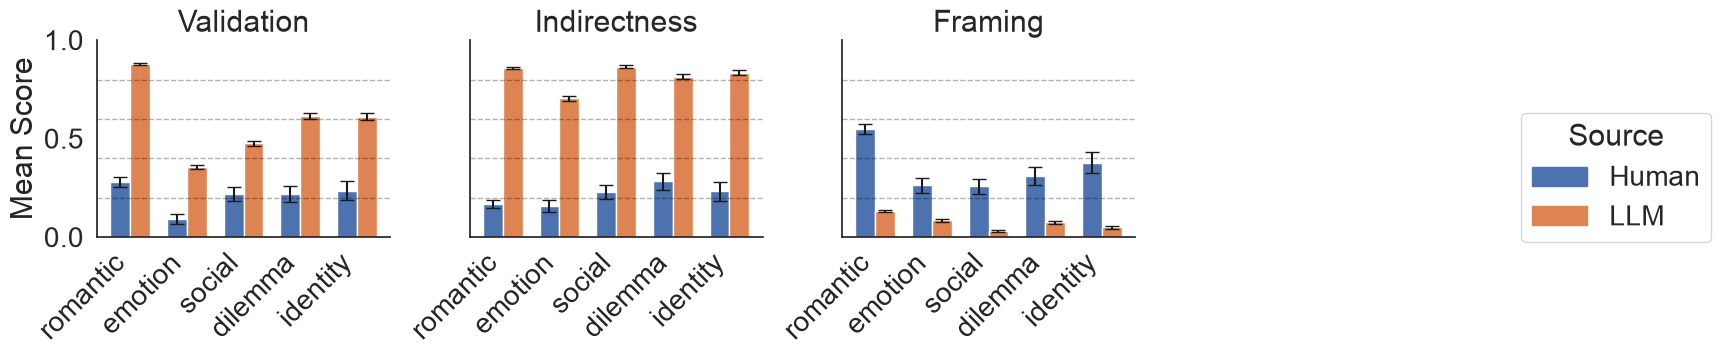

In [7]:


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
sns.set(font_scale = 1.8)
sns.set_style("white", {
    "font.family": "sans-serif",
    "font.serif": ['Helvetica'],
    "font.scale": 1.8
})
# Define subplot layout
n_rows, n_cols = 1, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4), sharex=True, sharey=True)
axes = axes.flatten()  # flatten to easily index

bar_handles = []  # Collect handles only once

for idx, metric in enumerate(metrics):
    metric_df = agg_df[agg_df['metric'] == metric]
    clusters = metric_df['cluster'].unique()
    x = np.arange(len(clusters))
    width = 0.35
    ax = axes[idx]

    for i, model_type in enumerate(['human', 'LLM']):
        mt_df = (
            metric_df[metric_df['model_type'] == model_type]
            .set_index('cluster')
            .reindex(clusters)
        )
        print(mt_df)
        if model_type == 'human':
            model_type = "Human"
        means = mt_df['value']
        errors = mt_df['sem'] if 'sem' in mt_df.columns else 0
        bars = ax.bar(x + i * width, means, width, yerr=errors, label=model_type, capsize=5)

        if idx == 0:
            bar_handles.append(mpatches.Patch(color=bars[0].get_facecolor(), label=model_type))

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(['romantic', 'emotion', 'social', 'dilemma', 'identity'], rotation=45, ha='right')
    if idx % n_cols == 0:
        ax.set_ylabel("Mean Score")
    m = metric.capitalize()
    ax.set_title(f"{m}")
    ax.set_ylim(0, 1)

    apply_style(ax)

# Turn off any unused subplots (if applicable)
for ax in axes[len(metrics):]:
    ax.axis('off')

# Adjust layout to leave space on the right for the legend
plt.tight_layout()
plt.subplots_adjust(right=0.85)

# Add figure-level legend on the right
fig.legend(
    handles=bar_handles,
    loc='center left',
    bbox_to_anchor=(0.85, 0.5),
    title="Source"
)

plt.savefig('clusters.pdf', bbox_inches='tight')
plt.show()
